# --------------------- Model Training, Evaluation & Validation ---------------------

####

# Project plan

#### Importing important packages

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import math as math
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier


from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

######

#### Importing cleaned dataset which earlier saved in pickle file

In [2]:
df = pd.read_pickle(r"C:\Users\Naveen\Desktop\GitHub\TransGlobe_Business\Classification_model\df.pkl")
train_x = pd.read_pickle(r"C:\Users\Naveen\Desktop\GitHub\TransGlobe_Business\Classification_model\train_x.pkl")
train_y = pd.read_pickle(r"C:\Users\Naveen\Desktop\GitHub\TransGlobe_Business\Classification_model\train_y.pkl")
test_x = pd.read_pickle(r"C:\Users\Naveen\Desktop\GitHub\TransGlobe_Business\Classification_model\test_x.pkl")
test_y = pd.read_pickle(r"C:\Users\Naveen\Desktop\GitHub\TransGlobe_Business\Classification_model\test_y.pkl")

######

# Model 1: Logistics Regression

In [3]:
# Model creation

param_grid = {'penalty' : ['l1', 'l2'], 'C': [ 0.25, 0.75]}
LR = GridSearchCV(LogisticRegression(),param_grid, verbose=True)
LR.fit(train_x, train_y)
LR.best_params_

Fitting 5 folds for each of 4 candidates, totalling 20 fits


{'C': 0.25, 'penalty': 'l2'}

In [4]:
# Predicting for train and test data

df_LR_train = pd.DataFrame({'Actual': train_y, 'Predicted': LR.predict(train_x)})
df_LR_test = pd.DataFrame({'Actual': test_y, 'Predicted': LR.predict(test_x)})

In [5]:
# Label encoding for y_variable

LE = LabelEncoder()

df_LR_test['Actual'] = LE.fit_transform(df_LR_test['Actual'])
df_LR_test['Predicted'] = LE.fit_transform(df_LR_test['Predicted'])


df_LR_train['Actual'] = LE.fit_transform(df_LR_train['Actual'])
df_LR_train['Predicted'] = LE.fit_transform(df_LR_train['Predicted'])

# Errors

In [6]:
# Classification report of Train data for Logistics regression

print(classification_report(df_LR_train.Actual, df_LR_train.Predicted))

              precision    recall  f1-score   support

           0       0.75      0.74      0.75     12160
           1       0.75      0.76      0.75     12160

    accuracy                           0.75     24320
   macro avg       0.75      0.75      0.75     24320
weighted avg       0.75      0.75      0.75     24320



In [7]:
# Classification report of Test data for Logistics regression

print(classification_report(df_LR_test.Actual, df_LR_test.Predicted))

              precision    recall  f1-score   support

           0       0.94      0.74      0.83      5275
           1       0.32      0.73      0.44       864

    accuracy                           0.74      6139
   macro avg       0.63      0.74      0.64      6139
weighted avg       0.86      0.74      0.78      6139



In [8]:
print('roc auc score of train data',roc_auc_score(df_LR_train.Actual, df_LR_train.Predicted))
print('roc auc score of test data',roc_auc_score(df_LR_test.Actual, df_LR_test.Predicted))

print("")

roc auc score of train data 0.7491776315789473
roc auc score of test data 0.7378086054063542



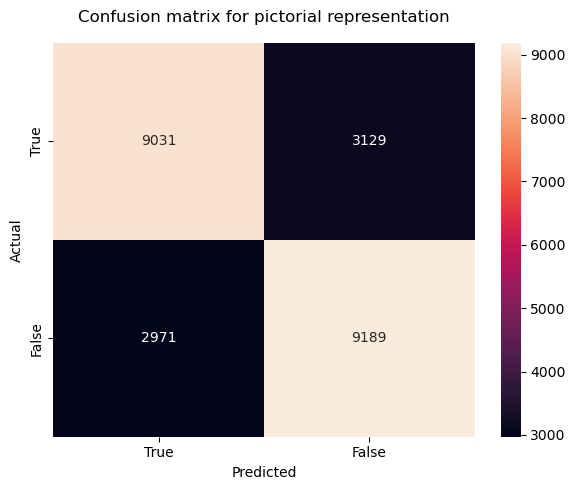

In [9]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_LR_train.Actual, df_LR_train.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

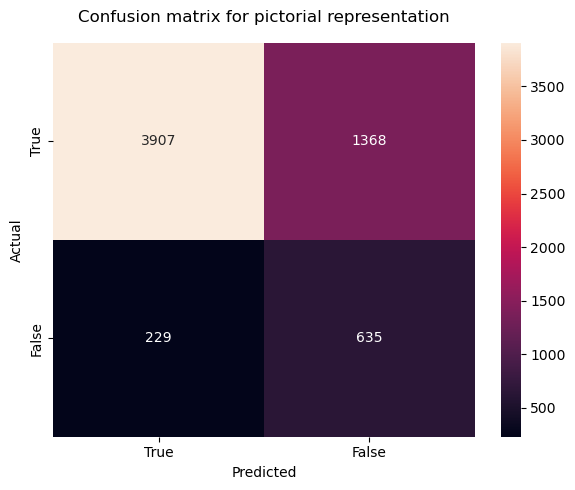

In [10]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_LR_test.Actual, df_LR_test.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### This model is working fine, having accuracy as 100% and recall and precision as 99%.
###

# Model 2: RandomForest

In [12]:
# Model creation

param_grid_rf = {'n_estimators' : [200,300], 'max_leaf_nodes' : [7,10]}
rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, verbose=True, cv=4)
rf.fit(train_x, train_y)
rf.best_params_

Fitting 2 folds for each of 1 candidates, totalling 2 fits


{'max_leaf_nodes': 7, 'n_estimators': 200}

In [13]:
df_rf_train = pd.DataFrame({'Actual': train_y, 'Predicted': rf.predict(train_x)})
df_rf_test = pd.DataFrame({'Actual': test_y, 'Predicted': rf.predict(test_x)})

# Errors

In [14]:
# Classification report of Train data for RandomForest

print(classification_report(df_rf_train.Actual, df_rf_train.Predicted))

              precision    recall  f1-score   support

           0       0.74      0.69      0.72     12160
           1       0.71      0.76      0.73     12160

    accuracy                           0.73     24320
   macro avg       0.73      0.73      0.73     24320
weighted avg       0.73      0.73      0.73     24320



In [15]:
# Classification report of Test data for RandomForest

print(classification_report(df_rf_test.Actual, df_rf_test.Predicted))

              precision    recall  f1-score   support

           0       0.94      0.68      0.79      5275
           1       0.28      0.74      0.40       864

    accuracy                           0.69      6139
   macro avg       0.61      0.71      0.60      6139
weighted avg       0.85      0.69      0.74      6139



In [16]:
print('roc auc score of train data',roc_auc_score(df_rf_train.Actual, df_rf_train.Predicted))
print('roc auc score of test data',roc_auc_score(df_rf_test.Actual, df_rf_test.Predicted))

print("")

roc auc score of train data 0.7261513157894737
roc auc score of test data 0.7133287256450763



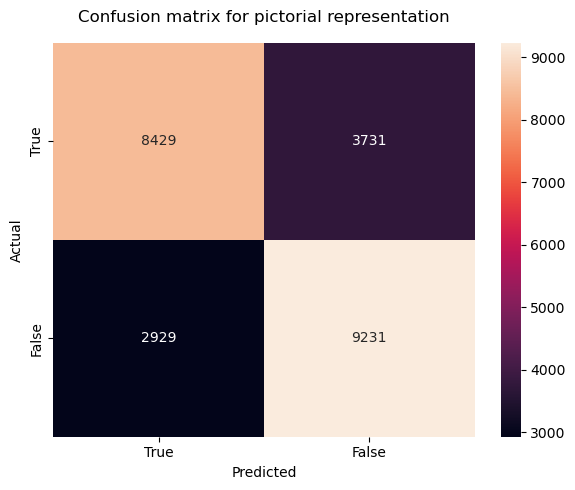

In [17]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_rf_train.Actual, df_rf_train.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

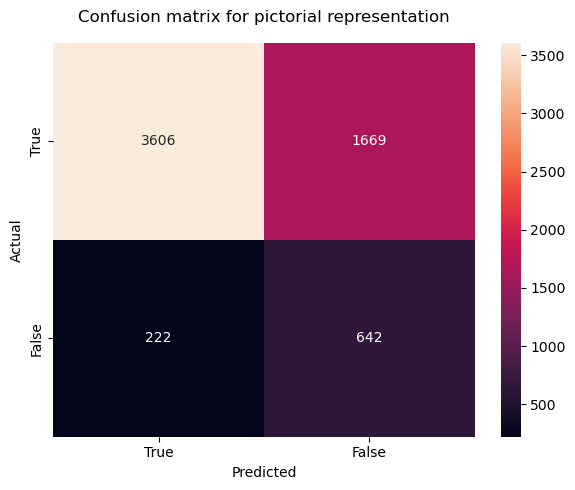

In [18]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_rf_test.Actual, df_rf_test.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

###
### Model 3: XGBoost

In [19]:
# Model creation

param_grid_xg = {'learning_rate' : [0.01, 0.05], 'n_estimators' : [100,300]}
xg = GridSearchCV(XGBClassifier(),param_grid_xg, verbose=True, cv=4)
xg.fit(train_x, train_y)
xg.best_params_

Fitting 2 folds for each of 1 candidates, totalling 2 fits


{'learning_rate': 0.01, 'n_estimators': 100}

In [20]:
df_xg_train = pd.DataFrame({'Actual': train_y, 'Predicted': xg.predict(train_x)})
df_xg_test = pd.DataFrame({'Actual': test_y, 'Predicted': xg.predict(test_x)})

# Errors

In [21]:
# Classification report of Train data for XGBoost

print(classification_report(df_xg_train.Actual, df_xg_train.Predicted))

              precision    recall  f1-score   support

           0       0.80      0.74      0.77     12160
           1       0.76      0.81      0.78     12160

    accuracy                           0.78     24320
   macro avg       0.78      0.78      0.78     24320
weighted avg       0.78      0.78      0.78     24320



In [22]:
# Classification report of Test data for XGBoost

print(classification_report(df_xg_test.Actual, df_xg_test.Predicted))

              precision    recall  f1-score   support

           0       0.95      0.73      0.82      5275
           1       0.31      0.74      0.44       864

    accuracy                           0.73      6139
   macro avg       0.63      0.73      0.63      6139
weighted avg       0.86      0.73      0.77      6139



In [23]:
print('roc auc score of train data',roc_auc_score(df_xg_train.Actual, df_xg_train.Predicted))
print('roc auc score of test data',roc_auc_score(df_xg_test.Actual, df_xg_test.Predicted))

print("")

roc auc score of train data 0.7772615131578948
roc auc score of test data 0.7348453133228015



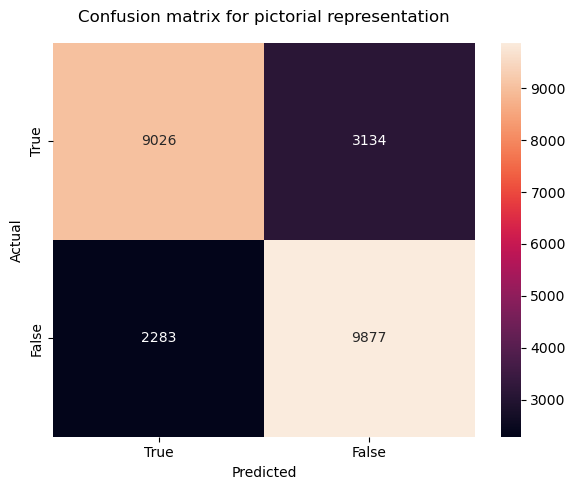

In [24]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_xg_train.Actual, df_xg_train.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

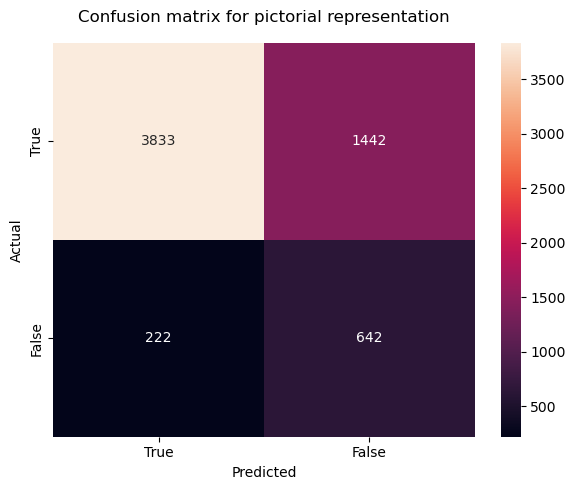

In [25]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_xg_test.Actual, df_xg_test.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Model 4: KNN

In [28]:
# Model creation

param_knn = {'n_neighbors' : [5,7], 'leaf_size' : [30, 50]}
knn = GridSearchCV(KNeighborsClassifier(), param_knn, verbose=True, cv=4)
knn.fit(train_x, train_y)
knn.best_params_

Fitting 2 folds for each of 1 candidates, totalling 2 fits


  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.

{'leaf_size': 30, 'n_neighbors': 7}

In [30]:
df_knn_train = pd.DataFrame({'Actual': train_y, 'Predicted': knn.predict(train_x)})
df_knn_test = pd.DataFrame({'Actual': test_y, 'Predicted': knn.predict(test_x)})

# Errors

In [31]:
# Classification report of Train data for KNN

print(classification_report(df_knn_train.Actual, df_knn_train.Predicted))

              precision    recall  f1-score   support

           0       0.96      0.73      0.83     12160
           1       0.78      0.97      0.86     12160

    accuracy                           0.85     24320
   macro avg       0.87      0.85      0.85     24320
weighted avg       0.87      0.85      0.85     24320



In [32]:
# Classification report of Test data for KNN

print(classification_report(df_knn_test.Actual, df_knn_test.Predicted))

              precision    recall  f1-score   support

           0       0.88      0.65      0.75      5275
           1       0.18      0.47      0.26       864

    accuracy                           0.63      6139
   macro avg       0.53      0.56      0.50      6139
weighted avg       0.78      0.63      0.68      6139



In [33]:
print('roc auc score of train data',roc_auc_score(df_knn_train.Actual, df_knn_train.Predicted))
print('roc auc score of test data',roc_auc_score(df_knn_test.Actual, df_knn_test.Predicted))

print("")

roc auc score of train data 0.8488075657894737
roc auc score of test data 0.5592839433034931



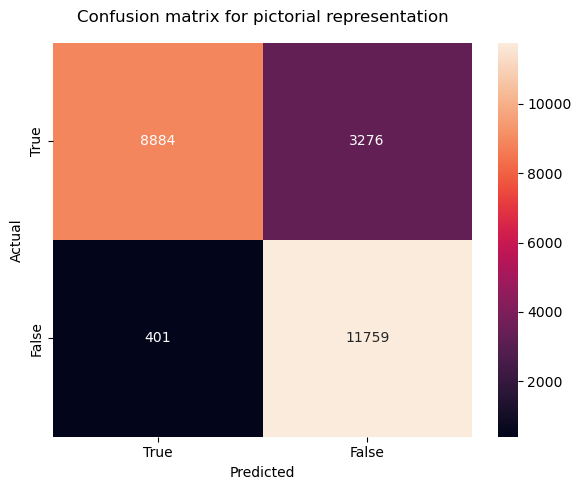

In [34]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_knn_train.Actual, df_knn_train.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

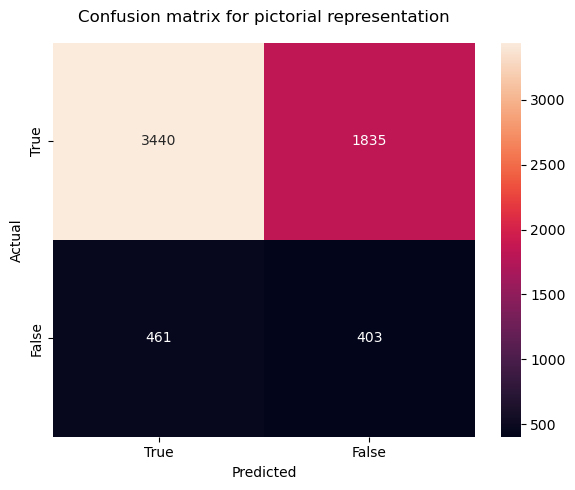

In [35]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_knn_test.Actual, df_knn_test.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [36]:
# Not running SVC coz it will too much time for this dataset (large dataset)

# Model 6: Gradient Boost

In [37]:
from sklearn.ensemble import GradientBoostingClassifier

In [38]:
# Model creation

param_gb = { 'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, 4] }
gb = GridSearchCV( GradientBoostingClassifier(random_state=42), param_gb, verbose=True, cv=4 )
gb.fit(train_x, train_y)
gb.best_params_

Fitting 2 folds for each of 1 candidates, totalling 2 fits


{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

In [39]:
df_gb_train = pd.DataFrame({'Actual': train_y, 'Predicted': gb.predict(train_x)})
df_gb_test = pd.DataFrame({'Actual': test_y, 'Predicted': gb.predict(test_x)})

# # Errors

In [40]:
# Classification report of Train data

print(classification_report(df_gb_train.Actual, df_gb_train.Predicted))

              precision    recall  f1-score   support

           0       0.80      0.77      0.78     12160
           1       0.78      0.80      0.79     12160

    accuracy                           0.79     24320
   macro avg       0.79      0.79      0.79     24320
weighted avg       0.79      0.79      0.79     24320



In [41]:
# Classification report of Test data

print(classification_report(df_gb_test.Actual, df_gb_test.Predicted))

              precision    recall  f1-score   support

           0       0.95      0.76      0.84      5275
           1       0.34      0.75      0.46       864

    accuracy                           0.76      6139
   macro avg       0.64      0.75      0.65      6139
weighted avg       0.86      0.76      0.79      6139



In [42]:
print('roc auc score of train data',roc_auc_score(df_gb_train.Actual, df_gb_train.Predicted))
print('roc auc score of test data',roc_auc_score(df_gb_test.Actual, df_gb_test.Predicted))

print("")

roc auc score of train data 0.7870888157894737
roc auc score of test data 0.7524207916447253



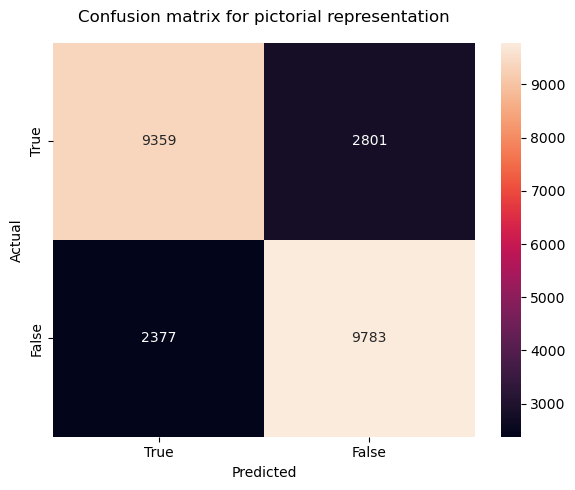

In [43]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_gb_train.Actual, df_gb_train.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

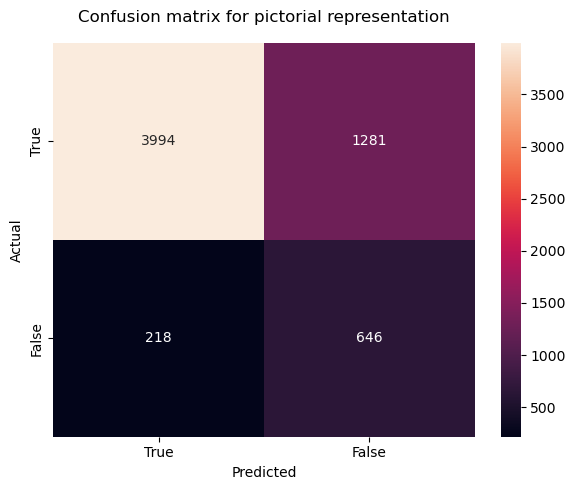

In [44]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(df_gb_test.Actual, df_gb_test.Predicted), annot=True, fmt='.0f', 
            xticklabels = ["True", "False"] , yticklabels = ["True", "False"])
plt.title('Confusion matrix for pictorial representation', pad=15)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [46]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

# List of model result DataFrames
models = {
    'Logistic Regression - Train': df_LR_train,
    'Logistic Regression - Test': df_LR_test,
    'Random Forest - Train': df_rf_train,
    'Random Forest - Test': df_rf_test,
    'XGBoost - Train': df_xg_train,
    'XGBoost - Test': df_xg_test,
    'KNN - Train': df_knn_train,
    'KNN - Test': df_knn_test,
    'Gradient Boosting - Train': df_gb_train,
    'Gradient Boosting - Test': df_gb_test
}

results = []

for model_name, df in models.items():

    precision, recall, f1, support = precision_recall_fscore_support(
        df['Actual'],
        df['Predicted'],
        labels=[1]
    )

    results.append({
        'Model': model_name,
        'Class 1 Precision': precision[0],
        'Class 1 Recall': recall[0],
        'Class 1 F1': f1[0]
    })

model_comparison = pd.DataFrame(results)

model_comparison

,Model,Class 1 Precision,Class 1 Recall,Class 1 F1
0,Logistic Regression - Train,0.745981,0.755674,0.750797
1,Logistic Regression - Test,0.317024,0.734954,0.442972
2,Random Forest - Train,0.712159,0.759128,0.734894
3,Random Forest - Test,0.277802,0.743056,0.404409
4,XGBoost - Train,0.759127,0.812253,0.784792
5,XGBoost - Test,0.308061,0.743056,0.435550
6,KNN - Train,0.782108,0.967023,0.864791
7,KNN - Test,0.180071,0.466435,0.259832
8,Gradient Boosting - Train,0.777416,0.804523,0.790737
9,Gradient Boosting - Test,0.335236,0.747685,0.462917


In [57]:
import pickle

# Creating a pickle of the best model
final_model = gb.best_estimator_

with open(
    "C:/Users/Naveen/Desktop/GitHub/TransGlobe_Business/Classification_model/final_model.pkl",
    "wb"
) as file:
    pickle.dump(final_model, file)